# Self-RAG (prompted version)

True Self-RAG fine-tunes reflection tokens into the generator. This implementation
emulates the same checks with prompted graders - the practical version for any LLM:

| Reflection token | Implemented by | Checks |
|---|---|---|
| ISREL | `retrieval_grader` | docs relevant to question? |
| ISSUP | `hallucination_grader` | generation grounded in docs? |
| ISUSE | `answer_grader` | generation addresses question? |

Differences vs CRAG: no router (always retrieves locally), no web fallback -
correction happens through REGENERATION and REWRITING instead.

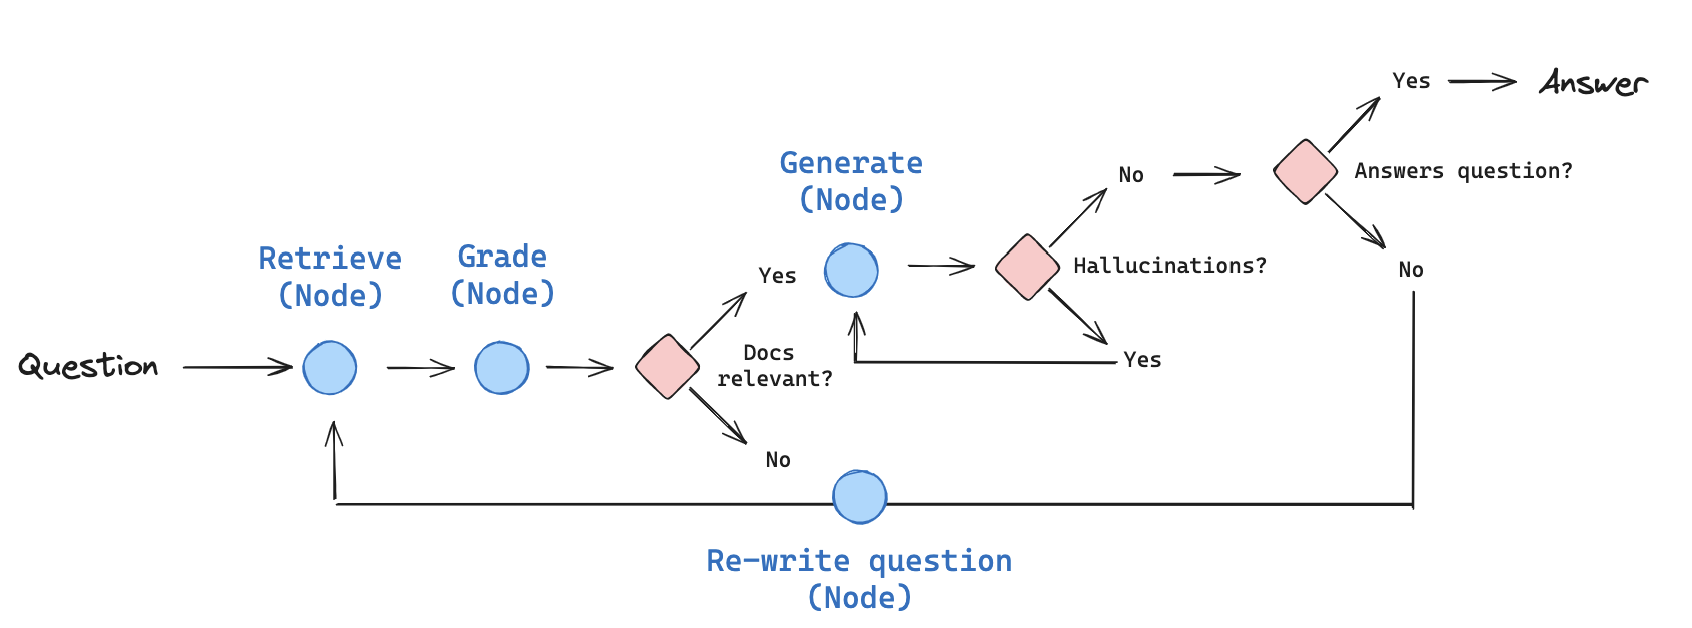
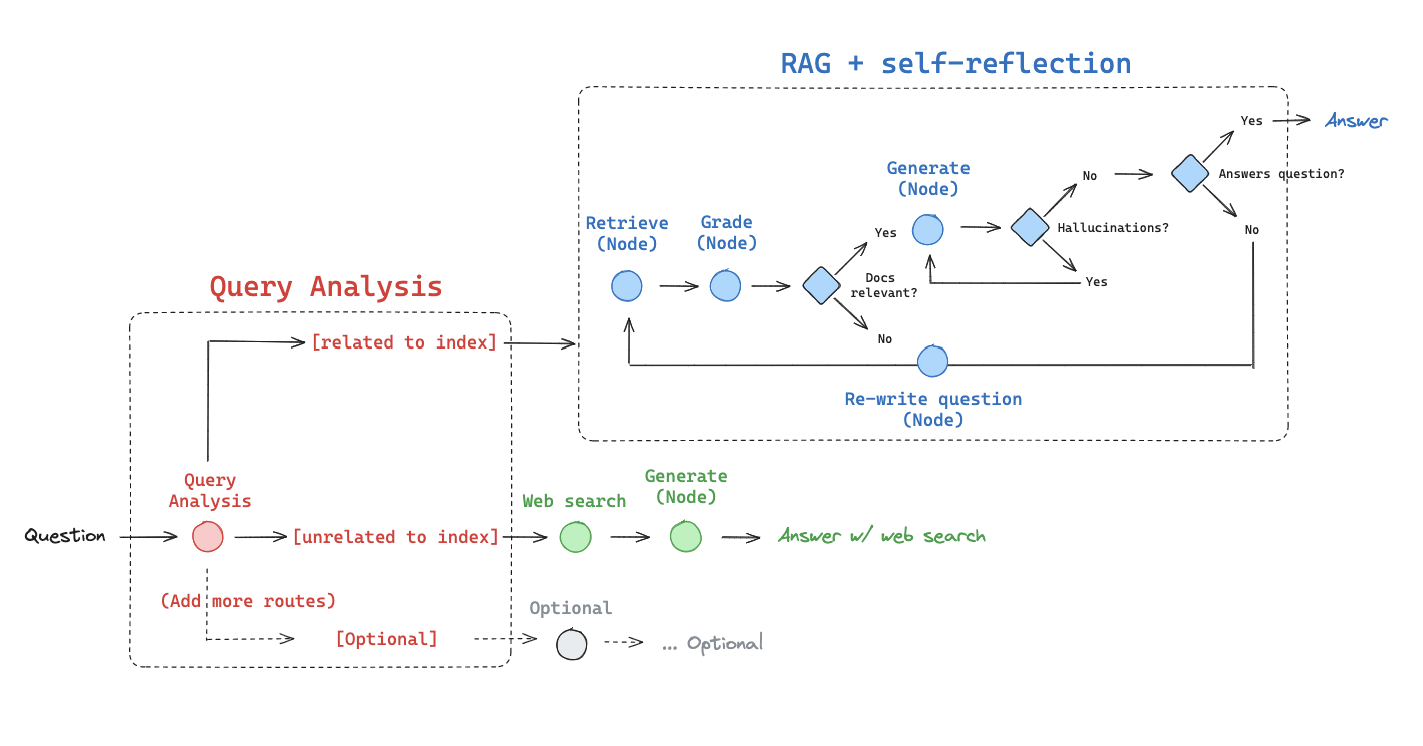
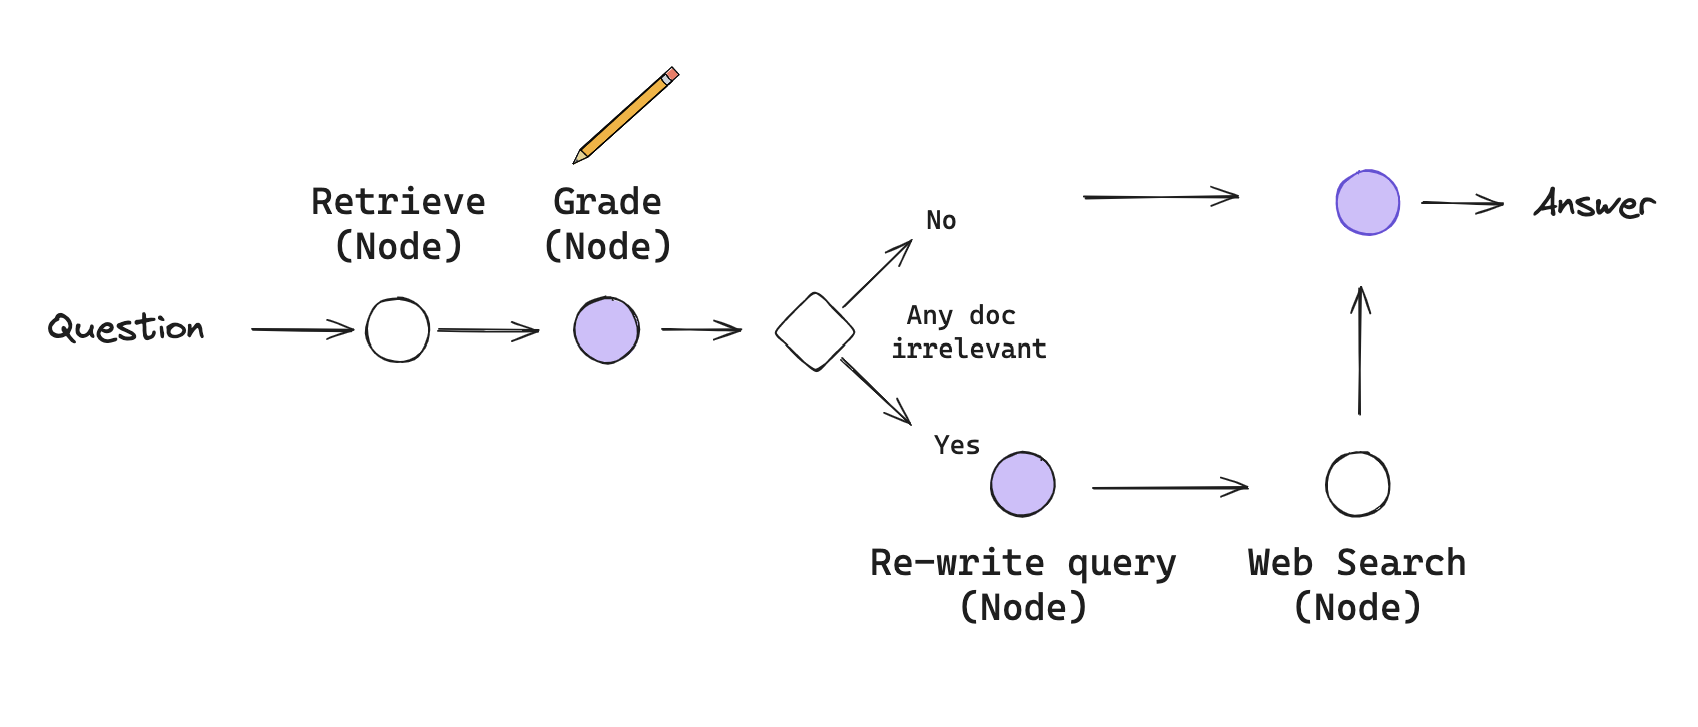

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"]="ARAG"

Same corpus again - graph structure is the experiment variable.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from langchain_core.documents import Document
import trafilatura

urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]


documents = []
for url in urls:
    downloaded = trafilatura.fetch_url(url)
    # Extracts main text and converts to markdown while stripping site chrome
    clean_text = trafilatura.extract(
        downloaded, 
        output_format="markdown", 
        include_links=False
    )
    if clean_text:
        documents.append(Document(page_content=clean_text, metadata={"source": url}))

text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=250, chunk_overlap=0
)
doc_splits = text_splitter.split_documents(documents)

# Add to vectorDB
vectorstore = Chroma.from_documents(
    documents=doc_splits,
    collection_name="rag-chroma",
    persist_directory=os.path.join(os.getcwd(), "chroma.db"),
    embedding=OllamaEmbeddings(model='nomic-embed-text'),
)
retriever = vectorstore.as_retriever()

Same generator chain as CRAG/ARAG.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field


class GradeDocs(BaseModel):
    """Binary score for releveant documents"""

    binary_score: str = Field(description="Documents are relevant to the question, 'yes' or 'no'")

llm = ChatOllama(model="gemma3:4b", temperature=0.1)
structured_llm = llm.with_structured_output(GradeDocs)

system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

retrieval_grader = grade_prompt | structured_llm

question = "agent memory"
docs = retriever.invoke(question)
doc_txt = docs[1].page_content
print(retrieval_grader.invoke({"question": question, "document": doc_txt}))

In [ ]:
from langchain_classic import hub
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template("""
# Role
You are an AI assistant focused on Question-Answering (QA) tasks within a Retrieval-Augmented Generation (RAG) system.
Your primary goal is to provide precise answers based on the given context or chat history.

# Instruction
Provide a concise, logical answer by organizing the selected content into coherent paragraphs with a natural flow. 
Avoid merely listing information. Include key numerical values, technical terms, jargon, and names. 
DO NOT use any outside knowledge or information that is not in the given material.

# Constraint
- Review the provided context thoroughly and extract key details related to the question.
- Craft a precise answer based on the relevant information.
- Keep the answer concise but logical/natural/in-depth.
- If the retrieved context does not contain relevant information or no context is available, respond with: 'I can't find the answer to that question in the context.'

**Source** (Optional)
- Cite the source of the information as a file name with a page number or URL, omitting the source if it cannot be identified.
- (list more if there are multiple sources)

# Question
<question>
{question}
</question>

# Context
<retrieved context>
{context}
</retrieved context>

# Answer
""" 
)

llm = ChatOllama(model="gemma3:4b")

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = prompt | llm | StrOutputParser()

generation = rag_chain.invoke({"context": docs, "question": question})
generation

ISSUP - THE defining Self-RAG check: is my own output supported by the evidence?
CRAG stops at grading inputs; Self-RAG grades its own work too.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field


class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )

llm = ChatOllama(model="gemma3:4b", temperature=0.1)
structured_llm_grader = llm.with_structured_output(GradeHallucinations)

system = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts. \n 
     Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."""
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

hallucination_grader = hallucination_prompt | structured_llm_grader
hallucination_grader.invoke({"documents": docs, "generation": generation})

ISUSE - grounded but evasive answers still fail here. Three gates must all pass.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field

class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )


llm = ChatOllama(model="gemma3:4b", temperature=0.1)
structured_llm_grader = llm.with_structured_output(GradeAnswer)

system = """You are a grader assessing whether an answer addresses / resolves a question \n 
     Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader
answer_grader.invoke({"question": question, "generation": generation})

Rewriter serves a different master than in CRAG: triggered when the ANSWER was weak
("not useful"), to retry local retrieval - there is no web escape hatch in this graph.

In [ ]:
llm = ChatOllama(model="gemma3:4b", temperature=0.1)

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for web search. Look at the input and try to reason about the underlying semantic intent / meaning. Respond only with the question"""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question": question})

Notice: NO `web_search` key in state - this graph has no fallback branch.

In [ ]:
from typing import List, TypedDict

class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """

    question: str
    generation: str
    documents: List[str]

In [ ]:
from langchain_core.documents import Document

def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}

In [ ]:
def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}

In [ ]:
def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each doc
    filtered_docs = []
    web_search = "No"
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            web_search = "Yes"
            continue
    return {"documents": filtered_docs, "question": question, "web_search": web_search}


In [ ]:
def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state["documents"]

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}

In [ ]:
def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    web_search = state["web_search"]
    state["documents"]

    if web_search == "Yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"

The double-gate edge function: ISSUP first (grounded?), then ISUSE (answers?).
Three exits: useful / not supported / not useful.

> Loop warning: `not supported -> generate` regenerates from the SAME context, and
> `not useful -> transform_query` re-enters the retrieve loop with no retry cap.
> If a small model keeps failing its own grades this can spin until LangGraph's
> default recursion_limit (25 supersteps) raises GraphRecursionError - your safety net.
> The `retries` counter pattern from Adaptive RAG is the proper fix if it bites.

In [ ]:
def grade_generation_v_documents_and_question(state):
    """
    Determines whether the generation is grounded in the document and answers question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Decision for next node to call
    """

    print("---CHECK HALLUCINATIONS---")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]

    score = hallucination_grader.invoke(
        {"documents": documents, "generation": generation}
    )
    grade = score.binary_score

    # Check hallucination
    if grade == "yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")
        # Check question-answering
        print("---GRADE GENERATION vs QUESTION---")
        score = answer_grader.invoke({"question": question, "generation": generation})
        grade = score.binary_score
        if grade == "yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"
        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"
    else:
        pprint("---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---")
        return "not supported"

### The whole flow

```mermaid
flowchart TD
    S([START]) --> RET[retrieve]
    RET --> GD[grade_docs]
    GD -->|docs ok| GEN[generate]
    GD -->|nothing| TQ[transform_query]
    TQ --> RET
    GEN -->|not supported| GEN
    GEN -->|not useful| TQ
    GEN -->|useful| E([END])
```

Cycles exist BY DESIGN here (self-reflection means retrying yourself) - bounded only by
LangGraph's recursion limit, not by the graph itself.

In [ ]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query

# Build graph
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "retrieve")
workflow.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "not supported": "generate",
        "useful": END,
        "not useful": "transform_query",
    },
)

# Compile
app = workflow.compile()

Out-of-corpus question: watch it fail ISREL repeatedly, rewrite, retry - and see whether
recursion_limit catches it or a lucky grade lets it through.

In [ ]:
from pprint import pprint

# Run
inputs = {
    "question": "What player at the Bears expected to draft first in the 2024 NFL draft?"
}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value["generation"])

In-domain question - should pass all three gates on the first or second pass.

In [ ]:
inputs = {"question": "What are the types of agent memory?"}
for output in app.stream(inputs):
    for key, value in output.items():
        # Node
        pprint(f"Node '{key}':")
        # Optional: print full state at each node
        # pprint.pprint(value["keys"], indent=2, width=80, depth=None)
    pprint("\n---\n")

# Final generation
pprint(value["generation"])